In [14]:
from dotenv import load_dotenv
load_dotenv()  # load API keys

from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from typing import List, Literal
from pydantic import BaseModel

In [2]:
# load the PDF document
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()
print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
# splits documents into chunk

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 900,
    chunk_overlap =150
)

chunks = splitter.split_documents(documents=raw_docs)

print(f' split into {len(chunks)} chunks')


 split into 51 chunks


In [4]:
# initialize the embedding model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [5]:
# in-memory only; re-running this cell re-embeds from scratch 
# create vectorestore.

vectorestore = Chroma(
    collection_name='rag_base',
    embedding_function=embeddings
)

vectorestore.add_documents(documents=chunks)

retriever = vectorestore.as_retriever(
    search_kwargs = {'k': 4}
)

print("Vector store ready")


Vector store ready


In [10]:
# Section 6 — LLM
llm = ChatOpenAI(model="gpt-5-mini")

In [6]:
# define the state of the graph.

class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: list[Document]
    context: str
    answer: str

    # new params
    need_retrieval : bool

In [11]:
# structure output for need-retrieval

class RouteDecision(BaseModel):

    need_retrieval: bool


## route_question node — classifies whether the query needs document retrieval
def route_question(state: AgenticRAGState) -> dict:

    prompt = ChatPromptTemplate.format_messages(
        [
            ('system',"Classify whether the following question requires retrieving information from a specialized document, or can be answered from your own general knowledge."),
            ('human', "{query}" )
        ]
    )

    chain = prompt | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({'query': state['query']})

    return {'need_retrieval', decision.need_retrieval}


In [12]:
def retrieve(state: AgenticRAGState):

    docs = retriever.invoke(state['query'])
    
    if docs:
     context = '\n\n'.join(doc.page_content for doc in docs)

    return {'retrieved_docs': docs, 'context': context}

In [13]:


def generate(state: AgenticRAGState):

    query = state['query']
    context = state['context']

    if context:

        prompt = ChatPromptTemplate.from_messages(
            [
                ("system","Answer the question using only the context below.\n\nContext:\n{context}"),
                ('human', "{query}")

            ]
        )
        response = (prompt | llm).invoke({'context': context, 'query': query})
        return {'answer': response.content}
    else:
        prompt = ChatPromptTemplate.from_messages([
            ('system', "Answer the following question from your general knowledge."),
            ("human", {'query'})
        ])
        response = (prompt | llm).inoke({'query': query})

        return {'answer': response.content}

In [15]:
# routing function: maps needs_retrieval bool to the next node name
def route_after_classification(state: AgenticRAGState) -> Literal['retrieve', 'generate']:

    if state['need_retrieval']:
        return 'retrieve'
    return 'generate'

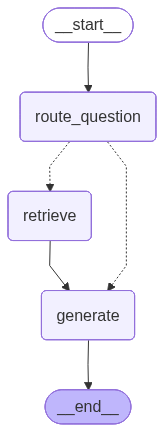

In [18]:
# define the stateGraph:

graph_builder = StateGraph(AgenticRAGState)

# add node
graph_builder.add_node('route_question', route_question)
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)


# add edge
graph_builder.add_edge(START, 'route_question')
graph_builder.add_conditional_edges('route_question', route_after_classification)
graph_builder.add_edge('generate', END)
graph_builder.add_edge('retrieve', 'generate')

graph = graph_builder.compile()


graph

In [ ]:
# Query 1: domain-specific (should trigger retrieval)
domain_query = "What does the report say about EV adoption trajectories and oil demand displacement?"

result_domain = graph.invoke({"query": domain_query, "messages": []})

In [ ]:
# Output: Query 1 (domain-specific)
print("=== QUERY 1 (domain-specific) ===")
print(f"Query          : {domain_query}")
print(f"needs_retrieval: {result_domain['needs_retrieval']}")
retrieved = result_domain.get("retrieved_docs") or []
print(f"Retrieved docs : {len(retrieved)} docs")
print(f"\nGeneration:\n{result_domain['generation']}")

In [ ]:
# Section 9 — Query 2: general knowledge (should skip retrieval)
general_query = "What is the capital of India?"

result_general = graph.invoke({"query": general_query, "messages": []})

In [ ]:
# Output: Query 2 (general knowledge)
print("=== QUERY 2 (general knowledge) ===")
print(f"Query          : {general_query}")
print(f"needs_retrieval: {result_general['needs_retrieval']}")
print(f"Retrieved docs : {result_general.get('retrieved_docs')}")
print(f"\nGeneration:\n{result_general['generation']}")